# Stage 6, Project: Customer Churn Prediction

**Problem:** predict which customers are likely to cancel their subscription (churn), using their account and service details.

**Dataset:** Telco Customer Churn (IBM sample dataset) — 7,043 customers, 21 columns, loaded directly from a public URL below.

New concepts this project introduces: handling a numeric column stored as text (a very common real-world data-quality issue), random forest as your first tree ensemble, and feature importances as a model-interpretation tool.

## 1. Load and first look

Guiding questions:
- What's the churn class balance? (Sets up the same majority-baseline check you've done every project so far.)
- Run `.info()` — does every column show the dtype you'd expect? Pay close attention to `TotalCharges`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"


# TODO: load with pd.read_csv(url)
data = pd.read_csv(url)



In [2]:
# TODO: .info(), .head(), Churn value_counts()

#data.info()
#data.head()
data.value_counts("Churn")

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 2. The TotalCharges problem

`TotalCharges` looks numeric when you eyeball the data, but if `.info()` showed it as `object` (text) instead of `float64`, that means at least one row has something non-numeric in that column — usually blank strings, sometimes literally the text `" "`.

**Syntax note:** `pd.to_numeric(series, errors='coerce')` tries to convert every value in a column to a number. The `errors='coerce'` argument tells it what to do when a value *can't* be converted: instead of crashing, it replaces that value with `NaN` (pandas' "missing value" marker). This turns an invisible data-quality bug into a visible, handleable missing value.

In [3]:
# TODO: df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# then check: how many rows became NaN? print df['TotalCharges'].isna().sum()
# look at those specific rows (df[df['TotalCharges'].isna()]) -- what do they have in common? (hint: check their 'tenure' column)

#churn_data = data.value_counts("Churn")
#no_churn_data = (churn_data["No"])
#yes_churn_data = (churn_data["Yes"])
#churn_rate = yes_churn_data / (yes_churn_data + no_churn_data)
#print(f"{churn_rate:.3f}")

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')


#print(data['TotalCharges'].isna().sum())
print((data[data['TotalCharges'].isna()]))






      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ... 

## 3. EDA

Guiding questions:
- Does churn rate differ by `Contract` type (month-to-month vs. one/two year)? Plot it — this is likely to be one of your strongest signals.
- Does churn rate differ by `tenure` (how long someone's been a customer)? Are new customers more or less likely to churn?
- Any columns that look redundant or unlikely to help (e.g., `customerID`)?

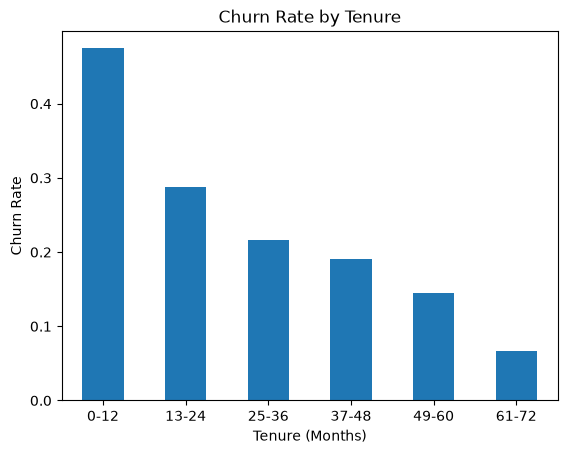

In [4]:
# TODO: churn rate by Contract type, churn rate by tenure (bucket tenure into groups if it helps the plot)

#data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})
#churn_rate_by_contract = data.groupby("Contract")["Churn"].mean()
#churn_rate_by_contract.plot(kind="bar")
#plt.xlabel("Contract Type")
#plt.ylabel("Churn Rate")
#plt.title("Churn Rate by Contract Type")
#plt.show()
 
# Reload your dataset
data = pd.read_csv(url)

# Convert Churn once
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Create tenure groups
data["tenure_group"] = pd.cut(
    data["tenure"],
    bins=[-1, 12, 24, 36, 48, 60, 72],
    labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"]
)

# Calculate churn rate
churn_rate_by_tenure = data.groupby(
    "tenure_group",
    observed=True
)["Churn"].mean()

churn_rate_by_tenure.plot(kind="bar")

plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Tenure")
plt.xticks(rotation=0)
plt.show()

## 4. Cleaning and feature prep

Steps:
- Drop `customerID` (a unique identifier carries no predictive signal, and could actually confuse a model if accidentally treated as a feature)
- Handle the `TotalCharges` NaNs from Section 2 (impute or drop — justify your choice given how few rows are affected)
- Encode `Churn` (target) from Yes/No to 1/0
- Split BEFORE any imputation/scaling (same leakage rule as always)
- Encode categorical features (`Contract`, `PaymentMethod`, `InternetService`, etc.) — there are more categorical columns here than in Titanic, so `pd.get_dummies` on a list of column names is more practical than encoding one at a time

**Syntax note:** `pd.get_dummies(df, columns=[...])` one-hot encodes every column you list in a single call, rather than needing a separate call per column.

In [5]:
from sklearn.model_selection import train_test_split

# 1. Drop customerID
data_new = data.drop(columns=["customerID"]).copy()

print(data["Churn"].unique())
print(data["Churn"].value_counts(dropna=False))


data_new["TotalCharges"] = pd.to_numeric(
    data_new["TotalCharges"],
    errors="coerce"
)


# 3. Separate X and y
X = data_new.drop(columns=["Churn"])
y = data_new["Churn"]

# 4. Train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

numeric_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include="object").columns

#print("Numeric:")
#print(numeric_features)

#print("\nCategorical:")
#print(categorical_features)



from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])



X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)








[0 1]
Churn
0    5174
1    1869
Name: count, dtype: int64


/var/folders/86/yy018mws3rx7chc2tz3qsm0w0000gn/T/ipykernel_87043/2201668495.py:38: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns


## 5. Baseline

Majority-class baseline accuracy — same check as every project so far. Given the class imbalance you likely found in Section 1, this number matters more than usual here.

In [6]:
# TODO: majority-class baseline accuracy


majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_val),
    majority_class
)

baseline_accuracy = (baseline_predictions == y_val).mean()

print("Majority class:", majority_class)
print("Baseline accuracy:", baseline_accuracy)

Majority class: 0
Baseline accuracy: 0.7348484848484849


## 6. Train and compare: Logistic Regression vs. Random Forest

You've used logistic regression before. Random forest is new — an ensemble of many decision trees, each trained on a random subset of the data and features, with predictions averaged/voted across all of them.

**Syntax note:** `RandomForestClassifier(n_estimators=100, random_state=42)` — `n_estimators` is how many individual trees to build (more trees = generally more stable, at the cost of speed; 100-300 is a common starting range). `random_state` fixes the randomness used in bootstrapping/feature selection so your results are reproducible run to run.

Guiding question: given that churn is imbalanced, which metric from Stage 5 should you actually be watching while comparing these two models — not just accuracy?

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# TODO: train both models on the same train set

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000)
logistic_regression_model.fit(
    X_train_processed,
    y_train
)
lr_val_pred = logistic_regression_model.predict(X_val_processed)
lr_val_prob = logistic_regression_model.predict_proba(X_val_processed)[:,1]


# Random Forest
random_forest_classifier_model = RandomForestClassifier(
    random_state=42
)
random_forest_classifier_model.fit(
    X_train_processed,
    y_train
)
rf_val_pred = random_forest_classifier_model.predict(X_val_processed)
rf_val_prob = random_forest_classifier_model.predict_proba(
    X_val_processed
)[:, 1]

## 7. Evaluate both models

Reuse your Stage 5 toolkit: confusion matrix, precision/recall/F1, ROC-AUC, PR-AUC — for both models, side by side.


Evaluation:
Logistic Regression performed better than Random Forest across all evaluation metrics. It achieved higher precision (0.646), recall (0.593), F1-score (0.618), ROC-AUC (0.845), and Average Precision (0.631). This suggests that Logistic Regression was better at both identifying customers likely to churn and distinguishing churners from non-churners. The ROC-AUC of 0.845 also indicates that the model has good ability to rank customers according to their likelihood of churning.

In [8]:
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

cm = confusion_matrix(y_val, lr_val_pred)

precision = precision_score(y_val, lr_val_pred)
recall = recall_score(y_val, lr_val_pred)
f1 = f1_score(y_val, lr_val_pred)

roc_auc = roc_auc_score(y_val, lr_val_prob)
average_precision = average_precision_score(y_val, lr_val_prob)
print("log regression: ")
print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print("Average Precision:", average_precision)


print("#"*70)
cm_rf = confusion_matrix(y_val, rf_val_pred)

precision_rf = precision_score(y_val, rf_val_pred)
recall_rf = recall_score(y_val, rf_val_pred)
f1_rf = f1_score(y_val, rf_val_pred)

roc_auc_rf = roc_auc_score(y_val, rf_val_prob)
average_precision_rf = average_precision_score(y_val, rf_val_prob)

print("Random Forest: ")
print("Confusion Matrix:\n", cm_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1:", f1_rf)
print("ROC-AUC:", roc_auc_rf)
print("Average Precision:", average_precision_rf)

log regression: 
Confusion Matrix:
 [[685  91]
 [114 166]]
Precision: 0.6459143968871596
Recall: 0.5928571428571429
F1: 0.6182495344506518
ROC-AUC: 0.8453124999999999
Average Precision: 0.6309718210450084
######################################################################
Random Forest: 
Confusion Matrix:
 [[680  96]
 [139 141]]
Precision: 0.5949367088607594
Recall: 0.5035714285714286
F1: 0.5454545454545454
ROC-AUC: 0.8105002761413844
Average Precision: 0.5755422212369714


## 8. Feature importances

One advantage random forest has over a black-box comparison: it can directly tell you which features it relied on most.

**Syntax note:** a fitted `RandomForestClassifier` has a `.feature_importances_` attribute — an array of scores (one per feature, same order as your training columns) representing roughly how much each feature contributed to reducing prediction error across all the trees. Higher = more influential. Pair it with your column names (`X_train.columns`) to see which features actually mattered, then sort descending and plot the top 10-15 as a horizontal bar chart.

45
45
                                feature  importance
3                     num__TotalCharges    0.159032
1                           num__tenure    0.138907
2                   num__MonthlyCharges    0.132668
36         cat__Contract_Month-to-month    0.049016
43  cat__PaymentMethod_Electronic check    0.032727
18               cat__OnlineSecurity_No    0.032600
16     cat__InternetService_Fiber optic    0.025068
27                  cat__TechSupport_No    0.024754
0                    num__SeniorCitizen    0.019952
21                 cat__OnlineBackup_No    0.019003
4                    cat__gender_Female    0.018285
39             cat__PaperlessBilling_No    0.017220
5                      cat__gender_Male    0.017172
40            cat__PaperlessBilling_Yes    0.016293
24             cat__DeviceProtection_No    0.015628


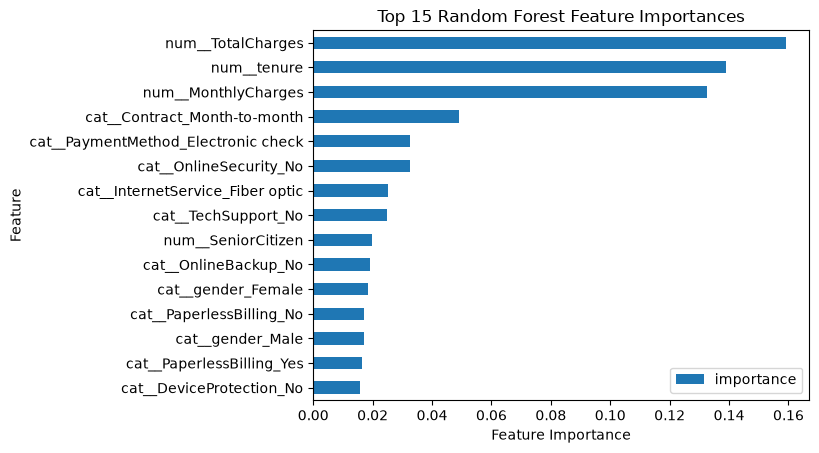

In [16]:
# TODO: extract feature_importances_ from your trained random forest, pair with column names, sort, plot top 10-15

feature_names = preprocessor.get_feature_names_out()
importances = random_forest_classifier_model.feature_importances_

print(len(importances))
print(len(feature_names))


feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)
print(feature_importance_df.head(15))

top_features = feature_importance_df.head(15)

top_features.plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()


## 9. Error analysis

Guiding questions:
- Pull out customers your best model got wrong (both false positives and false negatives). Do they share anything in common — similar contract type, similar tenure?
- Does the model's top feature importances line up with what your EDA in Section 3 already suggested was predictive? If not, that's worth investigating rather than ignoring.

In [29]:
# TODO: identify misclassified customers, look for patterns


false_positive_mask = (y_val == 0) & (lr_val_pred == 1)
false_positives = X_val[false_positive_mask].copy()
false_positives["actual"] = y_val[false_positive_mask]
false_positives["predicted"] = lr_val_pred[false_positive_mask]
###########################################################
false_negative_mask = (y_val == 1) & (lr_val_pred == 0)
false_negatives = X_val[false_negative_mask].copy()
false_negatives["actual"] = y_val[false_negative_mask]
false_negatives["predicted"] = lr_val_pred[false_negative_mask]

########################################################################

false_positives["InternetService"].value_counts()
false_negatives["InternetService"].value_counts()

print(feature_importance_df.head(15))

                                feature  importance
3                     num__TotalCharges    0.159032
1                           num__tenure    0.138907
2                   num__MonthlyCharges    0.132668
36         cat__Contract_Month-to-month    0.049016
43  cat__PaymentMethod_Electronic check    0.032727
18               cat__OnlineSecurity_No    0.032600
16     cat__InternetService_Fiber optic    0.025068
27                  cat__TechSupport_No    0.024754
0                    num__SeniorCitizen    0.019952
21                 cat__OnlineBackup_No    0.019003
4                    cat__gender_Female    0.018285
39             cat__PaperlessBilling_No    0.017220
5                      cat__gender_Male    0.017172
40            cat__PaperlessBilling_Yes    0.016293
24             cat__DeviceProtection_No    0.015628


In [35]:
error_analysis = X_val.copy()

error_analysis["actual"] = y_val
error_analysis["predicted"] = lr_val_pred

error_analysis["error_type"] = "Correct"

error_analysis.loc[
    (error_analysis["actual"] == 0) & (error_analysis["predicted"] == 1),
    "error_type"
] = "False Positive"

error_analysis.loc[
    (error_analysis["actual"] == 1) & (error_analysis["predicted"] == 0),
    "error_type"
] = "False Negative"

#print(error_analysis["error_type"].value_counts())


print(
    error_analysis.groupby("error_type")["tenure"].agg(
        ["mean", "median", "min", "max", "count"]
    )
)


pd.crosstab(
    error_analysis["Contract"],
    error_analysis["error_type"],
    normalize="index"
)


pd.crosstab(
    error_analysis["tenure_group"],
    error_analysis["error_type"],
    normalize="index"
)

                     mean  median  min  max  count
error_type                                        
Correct         34.102233    31.0    0   72    851
False Negative  27.245614    27.5    1   72    114
False Positive  14.175824    11.0    1   56     91


error_type,Correct,False Negative,False Positive
tenure_group,,,
0-12,0.718654,0.125382,0.155963
13-24,0.762500,0.093750,0.143750
25-36,0.794521,0.116438,0.089041
37-48,0.820000,0.150000,0.030000
49-60,0.868852,0.122951,0.008197
61-72,0.945274,0.054726,0.000000


## 10. Improvements to attempt

Pick at least one:
- Threshold tuning (Stage 5 technique) — given that missing a churner is probably costlier to a business than a false alarm, would you lower the default threshold?
- Try `class_weight='balanced'` on either model
- Cross-validate (Stage 5 technique) to confirm your single-split metrics are trustworthy before reporting them

In [36]:
# TODO: implement and evaluate at least one improvement

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    predictions = (lr_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, predictions)
    recall = recall_score(y_val, predictions)
    f1 = f1_score(y_val, predictions)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.2 | Precision: 0.473 | Recall: 0.879 | F1: 0.615
Threshold: 0.3 | Precision: 0.519 | Recall: 0.789 | F1: 0.626
Threshold: 0.4 | Precision: 0.561 | Recall: 0.707 | F1: 0.626
Threshold: 0.5 | Precision: 0.646 | Recall: 0.593 | F1: 0.618
Threshold: 0.6 | Precision: 0.723 | Recall: 0.411 | F1: 0.524
Threshold: 0.7 | Precision: 0.730 | Recall: 0.193 | F1: 0.305


## Wrap-up

Write a short summary, as if reporting to a business stakeholder:
- Which model won, and on which metric did you judge "winning"?
- What are the top 3 drivers of churn according to feature importances, and does that match business intuition?
- If the company could only act on one insight from this model, what would you recommend they do?

The logistic regression model "won" based on higher precision, recall and f1 score. The top 3 drivers of churn according to our random forest feature importances was total charges, tenure and monthly charges and it does match business intuition.

Based on the data, the company could proactively reach out to newer customers who are at higher risk of churning with retention offers and other personalized outreach. 